# Neural Network Classification with PyTorch

## Binaryclass Classification

In [1]:
from sklearn.datasets import make_circles

# Make 1000 samples
n_sample = 1000

# Create circles
X, y = make_circles(n_sample, noise=0.03, random_state=42)

In [2]:
len(X), len(y)

(1000, 1000)

In [3]:
print(f"First 5 samples of X:\n {X[:5]}")
print(f"First 5 samples of y:\n {y[:5]}")

First 5 samples of X:
 [[ 0.75424625  0.23148074]
 [-0.75615888  0.15325888]
 [-0.81539193  0.17328203]
 [-0.39373073  0.69288277]
 [ 0.44220765 -0.89672343]]
First 5 samples of y:
 [1 1 1 1 0]


In [4]:
# Make DataFrame of circle data
import pandas as pd

circles = pd.DataFrame({"X1": X[:, 0], 
                        "X2": X[:, 1],
                        "label": y})
circles.head(10)

,X1,X2,label
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0
5,-0.479646,0.676435,1
6,-0.013648,0.803349,1
7,0.771513,0.147760,1
8,-0.169322,-0.793456,1
9,-0.121486,1.021509,0


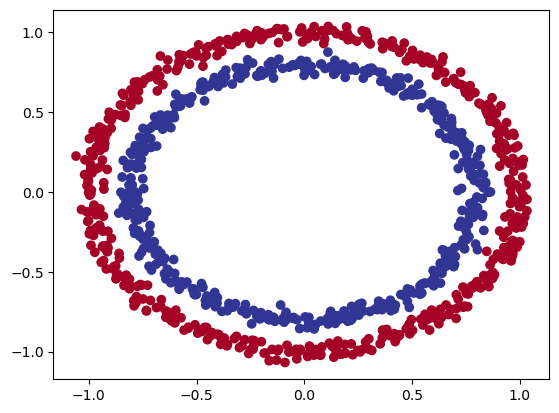

In [5]:
# Visualize
import matplotlib.pyplot as plt

plt.scatter(x=X[:, 0],
            y=X[:, 1],
            c=y,
            cmap=plt.cm.RdYlBu)

### 1.1 Check input and output shapes

In [6]:
X.shape, y.shape

((1000, 2), (1000,))

In [7]:
# View the first example of features and labels
X_sample = X[0]
y_sample = y[0]

print(f"Values for one sample of X: {X_sample} and the same for y: {y_sample}")
print(f"Shapes for one sample of X: {X_sample.shape} and the same for y: {y_sample.shape}")

Values for one sample of X: [0.75424625 0.23148074] and the same for y: 1
Shapes for one sample of X: (2,) and the same for y: ()


### 1.2 Turn data into tensors and create train and test splits

In [8]:
# Turn data into tensors
import torch

X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

X[:5], y[:5]

(tensor([[ 0.7542,  0.2315],
         [-0.7562,  0.1533],
         [-0.8154,  0.1733],
         [-0.3937,  0.6929],
         [ 0.4422, -0.8967]]),
 tensor([1., 1., 1., 1., 0.]))

In [9]:
# Split data into training and test sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
                                                    X,
                                                    y,
                                                    test_size=0.2, # 20%
                                                    random_state=42
                                                    )

In [10]:
len(X_train), len(X_test), len(y_train), len(y_test)

(800, 200, 800, 200)

## 2. Build a model

In [11]:
import torch
from torch import nn

device = "cuda" if torch.cuda.is_available() else "cpu"



Let's create a mode that:

1. Subclasses `nn.Module`
2. Create 2 `nn.Linear()` layers that capable of handling the shape of our data
3. Define a `forward()` method that outlines the forward pass of the model
4. Instantiate an instance of our model class and send it to target `device`

In [12]:
class CircleModelV1(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer_1 = nn.Linear(in_features=2, out_features=5) # takes in 2 features and upscale it to 5
    self.layer_2 = nn.Linear(in_features=5, out_features=1) # takes in 5 features from previous layer and output a single feature (same shape as y)

  def forward(self, x):
    return self.layer_2(self.layer_1(x)) # x -> Layer 1 -> Layer 2 -> Output

model_0 = CircleModelV1().to(device)
model_0

CircleModelV1(
  (layer_1): Linear(in_features=2, out_features=5, bias=True)
  (layer_2): Linear(in_features=5, out_features=1, bias=True)
)

In [13]:
next(model_0.parameters()).device

device(type='cpu')

In [14]:
# Let's recreate the model using nn.Sequential()
model_0 = nn.Sequential(
  nn.Linear(in_features=2, out_features=5),
  nn.Linear(in_features=5, out_features=1)
).to(device)

model_0

Sequential(
  (0): Linear(in_features=2, out_features=5, bias=True)
  (1): Linear(in_features=5, out_features=1, bias=True)
)

In [15]:
# Make predections
with torch.inference_mode():
  untrained_preds = model_0(X_test.to(device))
print(f"Length of predictions: {len(untrained_preds)}, Shape: {untrained_preds.shape}")
print(f"Length of test samples: {len(X_test)}, Shape: {X_test.shape}")
print(f"\nFirst 10 predictions:\n {torch.round(untrained_preds[:10])}")
print(f"\nFirst 10 labels:\n {y_test[:10]}")

Length of predictions: 200, Shape: torch.Size([200, 1])
Length of test samples: 200, Shape: torch.Size([200, 2])

First 10 predictions:
 tensor([[-0.],
        [-0.],
        [0.],
        [-0.],
        [0.],
        [0.],
        [-0.],
        [0.],
        [0.],
        [-0.]])

First 10 labels:
 tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.])


In [16]:
X_test[:10], y_test[:10]

(tensor([[-0.3752,  0.6827],
         [ 0.0154,  0.9600],
         [-0.7028, -0.3147],
         [-0.2853,  0.9664],
         [ 0.4024, -0.7438],
         [ 0.6323, -0.5711],
         [ 0.8561,  0.5499],
         [ 1.0034,  0.1903],
         [-0.7489, -0.2951],
         [ 0.0538,  0.9739]]),
 tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.]))

### 2.1 Setup loss function and optimizer

We can not use L1Loss again. It doesn't work for Classification models.

For regression we can use: MAE (mean absolute error) or MSE (mean squared error)
For classification: Binary Cross Entropy, Categorical Cross Entropy

For Optimizer for now we use SGD which handles different kinds of model type pretty decently.

In [17]:
# Setup loss function

# loss_fn = nn.BCELoss() # BCELoss = requires inputs to have gone through the sigmoid activation function prior to input to BCELoss
loss_fn = nn.BCEWithLogitsLoss() # BCEWithLogitsLoss = sigmoid activation function built-in

optimizer = torch.optim.SGD(model_0.parameters(), lr=0.1)

In [18]:
# Calculate accuracy 
def accuracy_fn(y_true, y_pred):
  correct = torch.eq(y_true, y_pred).sum().item()
  acc = (correct / len(y_pred)) * 100
  return acc

## 3. Train Model

1. Forward pass
2. Calculate the loss
3. Optimizer zero grad
4. Loss backward
5. Optimizer step

In [19]:
model_0.eval()
with torch.inference_mode():
  y_logits = model_0(X_test.to(device))[:5]
y_logits[:5]

tensor([[-0.1869],
        [-0.2315],
        [ 0.0947],
        [-0.2674],
        [ 0.3562]])

In [20]:
y_test[:5]

tensor([1., 0., 1., 0., 1.])

In [21]:
# Use sigmoid activation function on our model logits to turn them into prediction probabilities.
y_pred_probs = torch.sigmoid(y_logits)
y_pred_probs

tensor([[0.4534],
        [0.4424],
        [0.5237],
        [0.4336],
        [0.5881]])

In [22]:
# Find the predicted labels
y_preds = torch.round(y_pred_probs)

# In Full
y_pred_labels = torch.round(torch.sigmoid(model_0(X_test.to(device))[:5]))

print(torch.eq(y_preds.squeeze(), y_pred_labels.squeeze()))

# Get rid of extra dimention
y_preds.squeeze()

tensor([True, True, True, True, True])


tensor([0., 0., 1., 0., 1.])

In [23]:
## Building a training and testing loop

torch.manual_seed(42)

epochs = 1000

X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

for epoch in range(epochs):
  ### Training
  model_0.train()

  # 1. Forward pass
  y_logits = model_0(X_train).squeeze()
  y_pred = torch.round(torch.sigmoid(y_logits))

  # 2. Calculate the loss/accuracy
  loss = loss_fn(y_logits, y_train)
  acc = accuracy_fn(y_true=y_train, y_pred=y_pred)

  # 3. Optimizer zero grad
  optimizer.zero_grad()

  # 4. Loss backward
  loss.backward()

  # 5. Optimizer step
  optimizer.step()


  # Testing
  model_0.eval()
  with torch.inference_mode():
    # 1. Forward pass
    test_logits = model_0(X_test).squeeze()
    test_pred = torch.round(torch.sigmoid(test_logits))

    # 2. Calculate the test loss/acc
    test_loss = loss_fn(test_logits, y_test)
    test_acc = accuracy_fn(y_true=y_test, y_pred=test_pred)

  # Print out what's happening
  if epoch % 10 == 0:
    print(f"Epoch: {epoch} | Loss: {loss:.5f}, Acc: {acc:.2f} | Test Loss: {test_loss: .5f}")

Epoch: 0 | Loss: 0.70128, Acc: 50.50 | Test Loss:  0.69343
Epoch: 10 | Loss: 0.69971, Acc: 50.25 | Test Loss:  0.69273
Epoch: 20 | Loss: 0.69857, Acc: 50.25 | Test Loss:  0.69233
Epoch: 30 | Loss: 0.69768, Acc: 49.88 | Test Loss:  0.69209
Epoch: 40 | Loss: 0.69697, Acc: 49.88 | Test Loss:  0.69194
Epoch: 50 | Loss: 0.69639, Acc: 49.88 | Test Loss:  0.69186
Epoch: 60 | Loss: 0.69591, Acc: 50.12 | Test Loss:  0.69183
Epoch: 70 | Loss: 0.69550, Acc: 50.00 | Test Loss:  0.69184
Epoch: 80 | Loss: 0.69516, Acc: 50.00 | Test Loss:  0.69187
Epoch: 90 | Loss: 0.69487, Acc: 50.00 | Test Loss:  0.69192
Epoch: 100 | Loss: 0.69462, Acc: 50.00 | Test Loss:  0.69198
Epoch: 110 | Loss: 0.69441, Acc: 49.88 | Test Loss:  0.69206
Epoch: 120 | Loss: 0.69423, Acc: 49.88 | Test Loss:  0.69214
Epoch: 130 | Loss: 0.69407, Acc: 50.00 | Test Loss:  0.69223
Epoch: 140 | Loss: 0.69393, Acc: 50.12 | Test Loss:  0.69232
Epoch: 150 | Loss: 0.69381, Acc: 50.50 | Test Loss:  0.69241
Epoch: 160 | Loss: 0.69371, Acc: 50

In [24]:
# 4. make prediction and evaluate the model

import requests
from pathlib import Path

# Download Helper function
if Path("helper_functions.py").is_file():
  print("Helper functions file already exist")
else:
  print("Downloading the helper functions file...")
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/refs/heads/main/helper_functions.py")
  with open("helper_functions.py", "wb") as f:
    f.write(request.content)

from helper_functions import plot_predictions, plot_decision_boundary

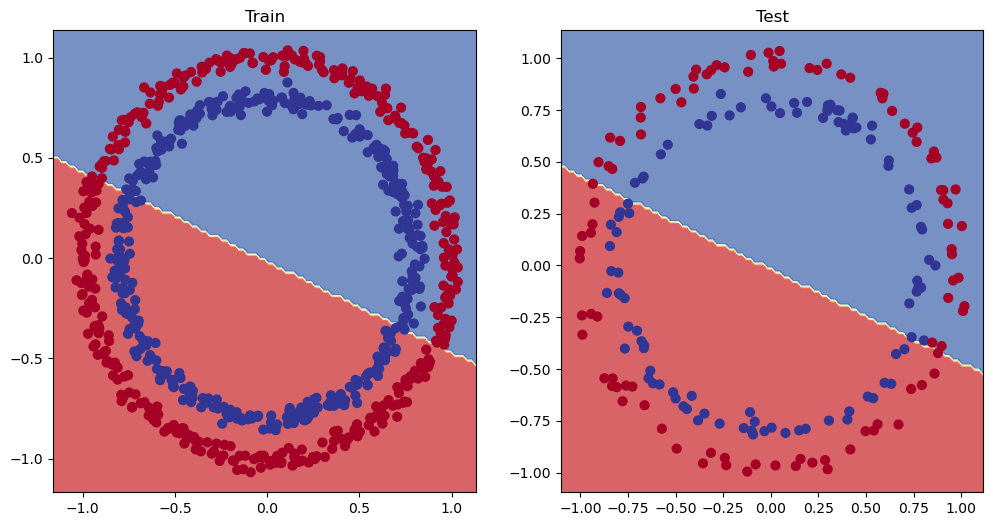

In [25]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2 ,1)
plt.title("Train")
plot_decision_boundary(model_0, X_train, y_train)
plt.subplot(1, 2 ,2)
plt.title("Test")
plot_decision_boundary(model_0, X_test, y_test)

**5. Improving a model (from a model perspective)**

- Add more layers - give the model more chances to learn about patterns in the data
- Add more hidden units - go from 5 hidden units to 10 hidden units
- Fit for longer
- Changing the activation functions
- Change the learning rate
- Change the loss function

These options are all from a model's prespective because they deal directly with the model rather than data.

In [26]:
# Add more hidden units 5 -> 10
# Increase the number of layer: 2 -> 3
# Increase the number of epochs: 100 -> 1000

class CircleModelV1(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer_1 = nn.Linear(in_features=2, out_features=10)
    self.layer_2 = nn.Linear(in_features=10, out_features=10)
    self.layer_3 = nn.Linear(in_features=10, out_features=1)

  def forward(self, x):
    # z = self.layer_1(x)
    # z = self.layer_2(z)
    # z = self.layer_3(z)
    return self.layer_3(self.layer_2(self.layer_1(x)))

model_1 = CircleModelV1().to(device)
model_1

CircleModelV1(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
)

In [27]:
# Create a loss function

loss_fn = nn.BCEWithLogitsLoss()

# Create an optimizer

optimizer = torch.optim.SGD(model_1.parameters(), lr=0.1)

In [28]:
torch.manual_seed(42)

epochs = 1000

X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

for epoch in range(epochs):
  ### Training
  model_1.train()

  # 1. Forward pass
  y_logits = model_1(X_train).squeeze()
  y_pred = torch.round(torch.sigmoid(y_logits))

  # 2. Calculate the loss/acc
  loss = loss_fn(y_logits, y_train)
  acc = accuracy_fn(y_train, y_pred)

  # 3. Optimizer zero grad
  optimizer.zero_grad()

  # 4. Loss backward
  loss.backward()

  # 5. Optimizer step
  optimizer.step()

  ### Test
  model_1.eval()
  with torch.inference_mode():
    # 1. Forward pass
    test_logits = model_1(X_test).squeeze()
    test_pred = torch.round(torch.sigmoid(test_logits))
    
    # 2. Calculate the loss/acc
    test_loss = loss_fn(test_logits, y_test)
    test_acc = accuracy_fn(y_test, test_pred)

  if epoch % 100 == 0:
    print(f"Epoch: {epoch} | Loss: {loss:.5f} | Accuracy: {acc:.2f}% | Test Loss: {test_loss:.5f} | Test Accuracy: {test_acc:.2f}%")

Epoch: 0 | Loss: 0.69396 | Accuracy: 50.88% | Test Loss: 0.69261 | Test Accuracy: 51.00%
Epoch: 100 | Loss: 0.69305 | Accuracy: 50.38% | Test Loss: 0.69379 | Test Accuracy: 48.00%
Epoch: 200 | Loss: 0.69299 | Accuracy: 51.12% | Test Loss: 0.69437 | Test Accuracy: 46.00%
Epoch: 300 | Loss: 0.69298 | Accuracy: 51.62% | Test Loss: 0.69458 | Test Accuracy: 45.00%
Epoch: 400 | Loss: 0.69298 | Accuracy: 51.12% | Test Loss: 0.69465 | Test Accuracy: 46.00%
Epoch: 500 | Loss: 0.69298 | Accuracy: 51.00% | Test Loss: 0.69467 | Test Accuracy: 46.00%
Epoch: 600 | Loss: 0.69298 | Accuracy: 51.00% | Test Loss: 0.69468 | Test Accuracy: 46.00%
Epoch: 700 | Loss: 0.69298 | Accuracy: 51.00% | Test Loss: 0.69468 | Test Accuracy: 46.00%
Epoch: 800 | Loss: 0.69298 | Accuracy: 51.00% | Test Loss: 0.69468 | Test Accuracy: 46.00%
Epoch: 900 | Loss: 0.69298 | Accuracy: 51.00% | Test Loss: 0.69468 | Test Accuracy: 46.00%


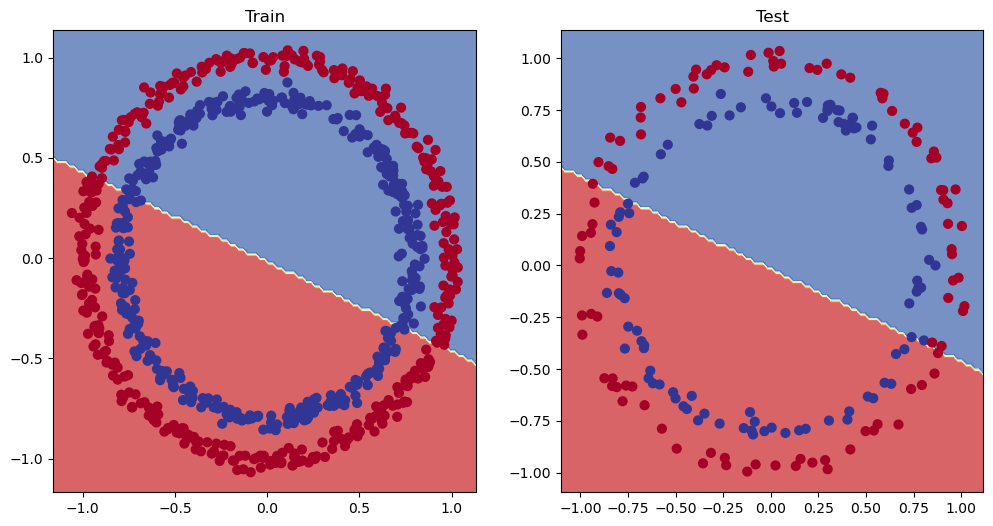

In [29]:
# Plot the decision boundary

plt.figure(figsize=(12, 6))
plt.subplot(1, 2 ,1)
plt.title("Train")
plot_decision_boundary(model_1, X_train, y_train)
plt.subplot(1, 2 ,2)
plt.title("Test")
plot_decision_boundary(model_1, X_test, y_test)

### 5.1 Preparing data to see if our model can fit a straight line

In [30]:
weight = 0.7
bias = 0.3

# Create
start = 0
end = 1
step = 0.01
X_regression = torch.arange(start, end, step).unsqueeze(dim=1)
y_regression = weight * X_regression + bias

X_regression[:10], y_regression[:10]

(tensor([[0.0000],
         [0.0100],
         [0.0200],
         [0.0300],
         [0.0400],
         [0.0500],
         [0.0600],
         [0.0700],
         [0.0800],
         [0.0900]]),
 tensor([[0.3000],
         [0.3070],
         [0.3140],
         [0.3210],
         [0.3280],
         [0.3350],
         [0.3420],
         [0.3490],
         [0.3560],
         [0.3630]]))

In [31]:
train_split = int(0.8 * len(X_regression))
X_train_regression, y_train_regression = X_regression[:train_split], y_regression[:train_split]
X_test_regression, y_test_regression = X_regression[train_split:], y_regression[train_split:]

len(X_train_regression), len(y_train_regression), len(X_test_regression), len(y_test_regression), 

(80, 80, 20, 20)

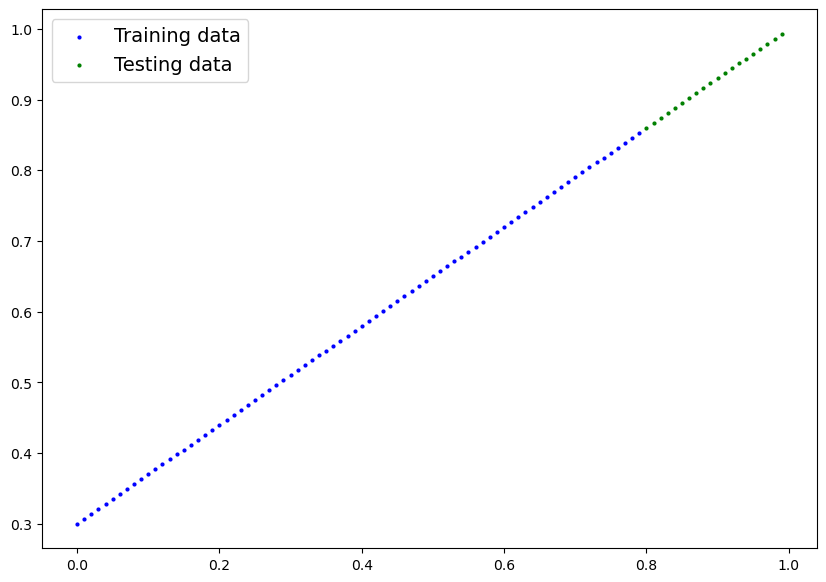

In [32]:
plot_predictions(train_data=X_train_regression,
                 train_labels=y_train_regression,
                 test_data=X_test_regression,
                 test_labels=y_test_regression)

### 5.2 Adjusting `model_1` to fit a straight line

In [33]:
# Same Architecture as model_1 (but using nn.Squential())

model_2 = nn.Sequential(
  nn.Linear(in_features=1, out_features=10),
  nn.Linear(in_features=10, out_features=10),
  nn.Linear(in_features=10, out_features=1),
).to(device)

model_2

Sequential(
  (0): Linear(in_features=1, out_features=10, bias=True)
  (1): Linear(in_features=10, out_features=10, bias=True)
  (2): Linear(in_features=10, out_features=1, bias=True)
)

In [34]:
# Loss and optimizer
loss_fn = nn.L1Loss()
optimizer = torch.optim.SGD(model_2.parameters(), lr=0.01)


In [35]:
# Train the model
torch.manual_seed(42)
epochs = 1000

X_train_regression, y_train_regression = X_train_regression.to(device), y_train_regression.to(device)
X_test_regression, y_test_regression = X_test_regression.to(device), y_test_regression.to(device)

for epoch in range(epochs):
  y_pred = model_2(X_train_regression)
  loss = loss_fn(y_pred, y_train_regression)
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  ### Testing
  model_2.eval()
  with torch.inference_mode():
    test_pred = model_2(X_test_regression)
    test_loss = loss_fn(test_pred, y_test_regression)

  if epoch % 100 == 0:
    print(f"Epoch: {epoch} | Loss: {loss:.5f} | Test Loss: {test_loss:.5f}")

Epoch: 0 | Loss: 0.75986 | Test Loss: 0.91103
Epoch: 100 | Loss: 0.02858 | Test Loss: 0.00081
Epoch: 200 | Loss: 0.02533 | Test Loss: 0.00209
Epoch: 300 | Loss: 0.02137 | Test Loss: 0.00305
Epoch: 400 | Loss: 0.01964 | Test Loss: 0.00341
Epoch: 500 | Loss: 0.01940 | Test Loss: 0.00387
Epoch: 600 | Loss: 0.01903 | Test Loss: 0.00379
Epoch: 700 | Loss: 0.01878 | Test Loss: 0.00381
Epoch: 800 | Loss: 0.01840 | Test Loss: 0.00329
Epoch: 900 | Loss: 0.01798 | Test Loss: 0.00360


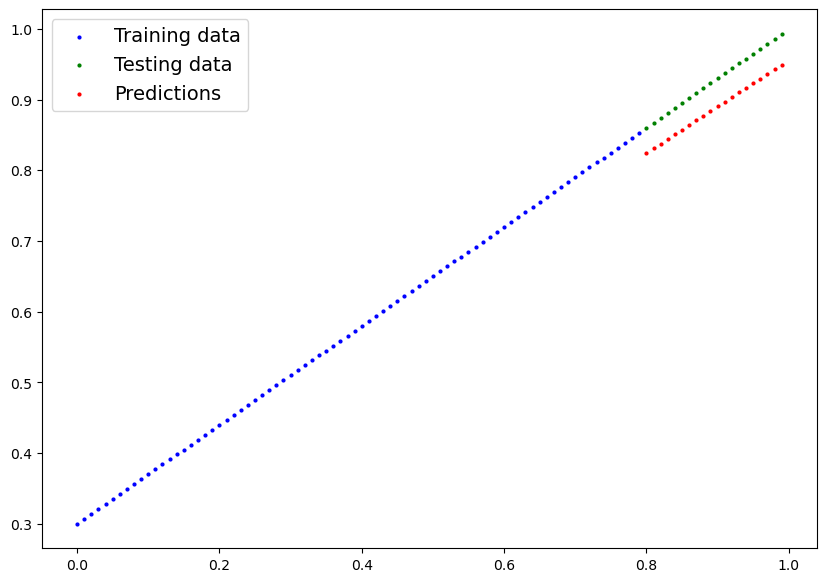

In [36]:
model_2.eval()
with torch.inference_mode():
  y_preds = model_2(X_test_regression)

plot_predictions(train_data=X_train_regression,
                 train_labels=y_train_regression,
                 test_data=X_test_regression,
                 test_labels=y_test_regression,
                 predictions=y_preds)

## 6. The missing piece: non-linearity

### 6.1 Recreating non-linear data (red and blue circles)

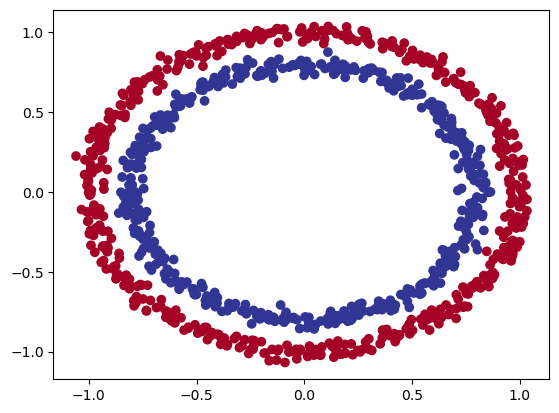

In [37]:
# Make and plot data
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles

n_samples = 1000

X, y = make_circles(n_samples, noise=0.03, random_state=42)

plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdYlBu)

In [38]:
import torch
from sklearn.model_selection import train_test_split

X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train[:5], y_train[:5],

(tensor([[ 0.6579, -0.4651],
         [ 0.6319, -0.7347],
         [-1.0086, -0.1240],
         [-0.9666, -0.2256],
         [-0.1666,  0.7994]]),
 tensor([1., 0., 0., 0., 1.]))

In [39]:
from torch import nn

class CircleModelV2(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer_1 = nn.Linear(in_features=2, out_features=10)
    self.layer_2 = nn.Linear(in_features=10, out_features=10)
    self.layer_3 = nn.Linear(in_features=10, out_features=1)
    self.relu = nn.ReLU()

  def forward(self, x):
    return self.layer_3(self.relu(self.layer_2(self.relu(self.layer_1(x)))))

model_3 = CircleModelV2().to(device)
model_3

CircleModelV2(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
  (relu): ReLU()
)

In [40]:
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(model_3.parameters(), lr=0.1)

torch.manual_seed(42)

epochs = 1000

X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

for epoch in range(epochs):
  ### Training
  model_3.train()

  # 1. Forward pass
  y_logits = model_3(X_train).squeeze()
  y_pred = torch.round(torch.sigmoid(y_logits))

  # 2. Calculate the loss/acc
  loss = loss_fn(y_logits, y_train)
  acc = accuracy_fn(y_train, y_pred)

  # 3. Optimizer zero grad
  optimizer.zero_grad()

  # 4. Loss backward
  loss.backward()

  # 5. Optimizer step
  optimizer.step()

  ### Test
  model_3.eval()
  with torch.inference_mode():
    # 1. Forward pass
    test_logits = model_3(X_test).squeeze()
    test_pred = torch.round(torch.sigmoid(test_logits))
    
    # 2. Calculate the loss/acc
    test_loss = loss_fn(test_logits, y_test)
    test_acc = accuracy_fn(y_test, test_pred)

  if epoch % 100 == 0:
    print(f"Epoch: {epoch} | Loss: {loss:.5f} | Accuracy: {acc:.2f}% | Test Loss: {test_loss:.5f} | Test Accuracy: {test_acc:.2f}%")

Epoch: 0 | Loss: 0.69295 | Accuracy: 50.00% | Test Loss: 0.69319 | Test Accuracy: 50.00%
Epoch: 100 | Loss: 0.69115 | Accuracy: 52.88% | Test Loss: 0.69102 | Test Accuracy: 52.50%
Epoch: 200 | Loss: 0.68977 | Accuracy: 53.37% | Test Loss: 0.68940 | Test Accuracy: 55.00%
Epoch: 300 | Loss: 0.68795 | Accuracy: 53.00% | Test Loss: 0.68723 | Test Accuracy: 56.00%
Epoch: 400 | Loss: 0.68517 | Accuracy: 52.75% | Test Loss: 0.68411 | Test Accuracy: 56.50%
Epoch: 500 | Loss: 0.68102 | Accuracy: 52.75% | Test Loss: 0.67941 | Test Accuracy: 56.50%
Epoch: 600 | Loss: 0.67515 | Accuracy: 54.50% | Test Loss: 0.67285 | Test Accuracy: 56.00%
Epoch: 700 | Loss: 0.66659 | Accuracy: 58.38% | Test Loss: 0.66322 | Test Accuracy: 59.00%
Epoch: 800 | Loss: 0.65160 | Accuracy: 64.00% | Test Loss: 0.64757 | Test Accuracy: 67.50%
Epoch: 900 | Loss: 0.62362 | Accuracy: 74.00% | Test Loss: 0.62145 | Test Accuracy: 79.00%


### 6.4 Evaluating our new model

In [41]:
model_3.eval()
with torch.inference_mode():
  y_preds = torch.round(torch.sigmoid(model_3(X_test))).squeeze()

y_preds[:10], y_test[:10]

(tensor([1., 0., 1., 0., 0., 1., 0., 0., 1., 0.]),
 tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.]))

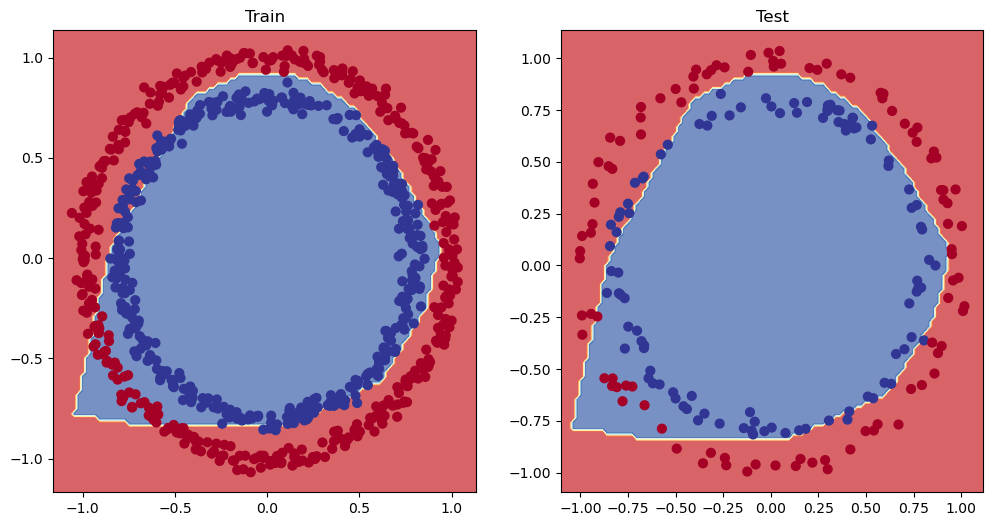

In [42]:
# Plot the decision boundary

plt.figure(figsize=(12, 6))
plt.subplot(1, 2 ,1)
plt.title("Train")
plot_decision_boundary(model_3, X_train, y_train)
plt.subplot(1, 2 ,2)
plt.title("Test")
plot_decision_boundary(model_3, X_test, y_test)

## 7. Replication non-linear activation functions

In [43]:
# Create a tensor
A = torch.arange(-10, 10, 1, dtype=torch.float32)
A

tensor([-10.,  -9.,  -8.,  -7.,  -6.,  -5.,  -4.,  -3.,  -2.,  -1.,   0.,   1.,
          2.,   3.,   4.,   5.,   6.,   7.,   8.,   9.])

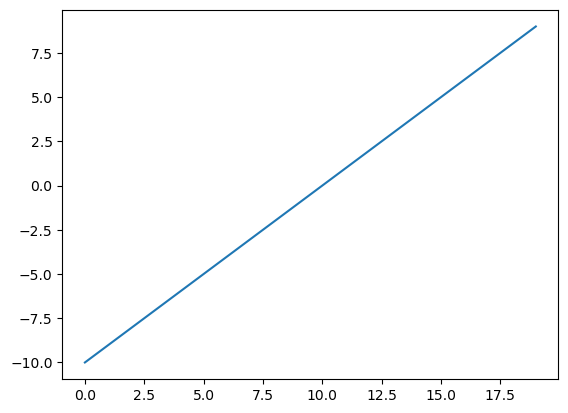

In [44]:
plt.plot(A)

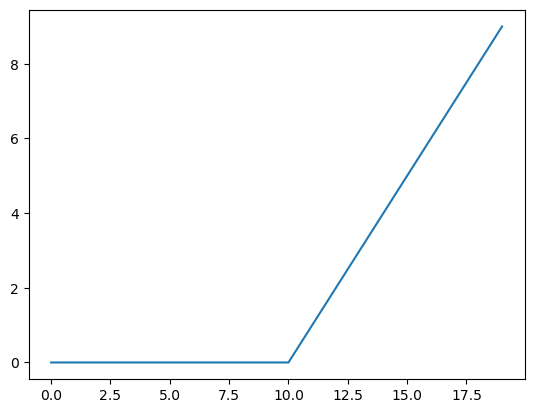

In [45]:
plt.plot(torch.relu(A))

In [46]:
def relu(x):
  return torch.maximum(torch.tensor(0), x)

relu(A)

tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 2., 3., 4., 5., 6., 7.,
        8., 9.])

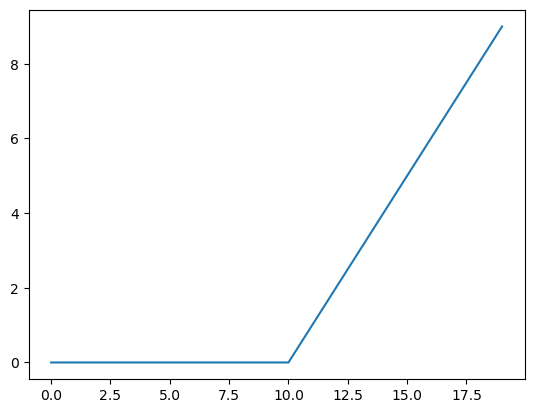

In [47]:
plt.plot(relu(A))

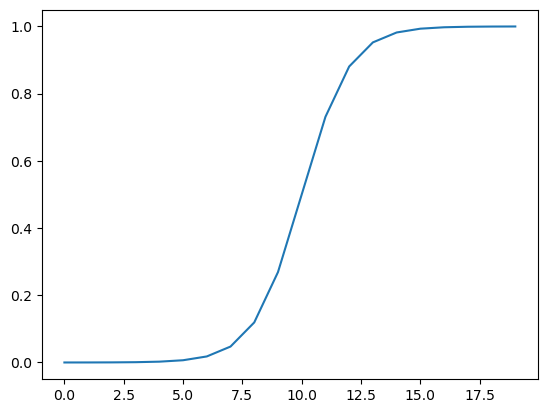

In [48]:
plt.plot(torch.sigmoid(A))

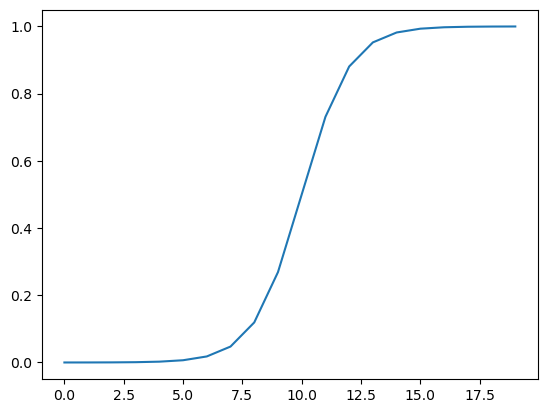

In [49]:
def sigmoid(x):
  return 1 / (1 + torch.exp(-x))

plt.plot(sigmoid(A))

## Multiclass Classification

### 8.1 Creating a toy multi-class datasets

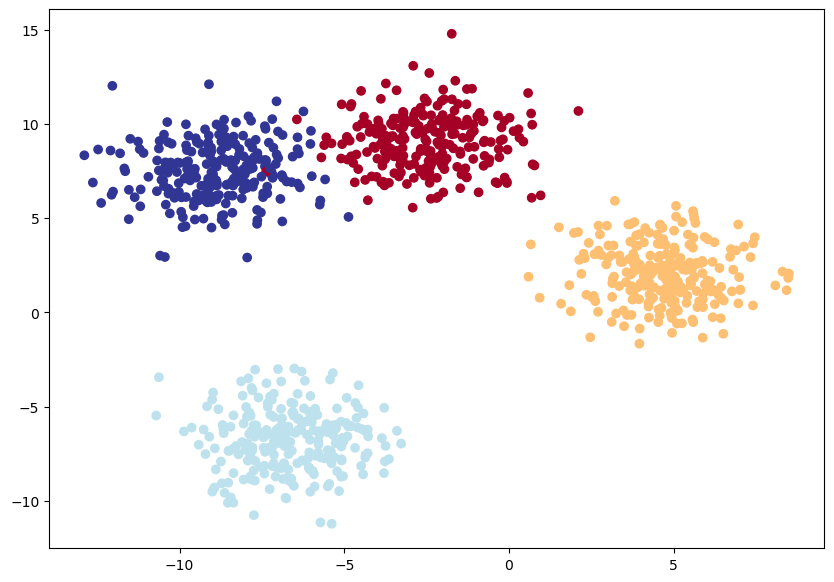

In [50]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split

# Set the hyperparameters
NUM_CLASSES = 4
NUM_FEATURES = 2
RANDOM_SEED = 42

# 1. Create multi-class data
X_blob, y_blob = make_blobs(n_samples=1000,
                            n_features=NUM_FEATURES,
                            centers=NUM_CLASSES,
                            cluster_std= 1.5,
                            random_state=RANDOM_SEED)

X_blob = torch.from_numpy(X_blob).type(torch.float)
y_blob = torch.from_numpy(y_blob).type(torch.float)

# 2. Split into train and test
X_blob_train, X_blob_test, y_blob_train, y_blob_test = train_test_split(X_blob, y_blob, test_size=0.2, random_state=RANDOM_SEED)

# 3. Plot Data
plt.figure(figsize=(10, 7))
plt.scatter(X_blob[:, 0], X_blob[:, 1], c=y_blob, cmap=plt.cm.RdYlBu)

### 8.2 Build a multi-class classification model

In [51]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [52]:
class BlobModelV1(nn.Module):
  def __init__(self, input_features, output_features, hidden_units=8):
    super().__init__()
    self.linear_layer_stack = nn.Sequential(
      nn.Linear(in_features=input_features, out_features=hidden_units),
      nn.ReLU(),
      nn.Linear(in_features=hidden_units, out_features=hidden_units),
      nn.ReLU(),
      nn.Linear(in_features=hidden_units, out_features=output_features),
    )
  def forward(self, x):
    return self.linear_layer_stack(x)

In [53]:
model_4 = BlobModelV1(input_features=2, output_features=4).to(device)

model_4

BlobModelV1(
  (linear_layer_stack): Sequential(
    (0): Linear(in_features=2, out_features=8, bias=True)
    (1): ReLU()
    (2): Linear(in_features=8, out_features=8, bias=True)
    (3): ReLU()
    (4): Linear(in_features=8, out_features=4, bias=True)
  )
)

### 8.3 Creating a loss function and an optimizer

In [54]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model_4.parameters(), lr=0.1)

### 8.4 Getting prediction probabilites for a multi-class model

Logits (raw output of the model) -> Pred probs (use `torch.softmax`) -> Pred labels (take the `argmax` of the prediction probabilites)

In [55]:
model_4.eval()
with torch.inference_mode():
  y_logits = model_4(X_blob_test)

y_logits[:10]

tensor([[-0.7646, -0.7412, -1.5777, -1.1376],
        [-0.0973, -0.9431, -0.5963, -0.1371],
        [ 0.2528, -0.2379,  0.1882, -0.0066],
        [-0.4134, -0.5204, -0.9303, -0.6963],
        [-0.3118, -1.3736, -1.1991, -0.3834],
        [-0.1497, -1.0617, -0.7107, -0.1645],
        [ 0.1539, -0.2887,  0.1520, -0.0109],
        [-0.2154, -1.1795, -0.9300, -0.2745],
        [ 0.2443, -0.2472,  0.1649,  0.0061],
        [-0.2329, -1.2120, -0.9849, -0.3004]])

In [56]:
y_blob_test[:10]

tensor([1., 3., 2., 1., 0., 3., 2., 0., 2., 0.])

In [57]:
y_pred_probs = torch.softmax(y_logits, dim=1)
print(y_logits[:5])
print(y_pred_probs[:5])

tensor([[-0.7646, -0.7412, -1.5777, -1.1376],
        [-0.0973, -0.9431, -0.5963, -0.1371],
        [ 0.2528, -0.2379,  0.1882, -0.0066],
        [-0.4134, -0.5204, -0.9303, -0.6963],
        [-0.3118, -1.3736, -1.1991, -0.3834]])
tensor([[0.3169, 0.3244, 0.1405, 0.2182],
        [0.3336, 0.1432, 0.2026, 0.3206],
        [0.3011, 0.1843, 0.2823, 0.2323],
        [0.3078, 0.2766, 0.1836, 0.2320],
        [0.3719, 0.1286, 0.1532, 0.3463]])


In [58]:
# Convert our model's prediction probabilities to prediction labels
y_preds = torch.argmax(y_pred_probs, dim=1)
y_preds

tensor([1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 3, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
        1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3, 0, 0, 1, 0, 1, 0, 0, 0,
        0, 0, 0, 0, 3, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
        1, 0, 0, 0, 0, 1, 0, 1])

In [59]:
y_blob_test

tensor([1., 3., 2., 1., 0., 3., 2., 0., 2., 0., 0., 1., 0., 0., 0., 3., 3., 2.,
        3., 3., 3., 0., 1., 2., 2., 2., 3., 0., 1., 0., 3., 1., 1., 3., 1., 2.,
        1., 3., 0., 2., 0., 3., 3., 2., 0., 3., 1., 1., 0., 3., 1., 0., 1., 1.,
        3., 2., 1., 1., 3., 2., 2., 0., 3., 2., 2., 0., 0., 3., 3., 0., 0., 3.,
        3., 3., 2., 3., 3., 3., 3., 1., 0., 2., 3., 2., 3., 3., 2., 3., 3., 2.,
        3., 3., 1., 3., 3., 3., 1., 0., 3., 2., 0., 0., 3., 0., 2., 3., 1., 0.,
        3., 2., 1., 1., 0., 2., 2., 3., 0., 0., 1., 2., 2., 3., 0., 1., 2., 0.,
        0., 0., 2., 3., 1., 2., 3., 2., 0., 3., 0., 0., 1., 1., 1., 0., 2., 2.,
        2., 2., 0., 3., 3., 2., 2., 1., 3., 2., 0., 0., 3., 3., 2., 1., 2., 0.,
        3., 2., 0., 3., 2., 0., 2., 2., 2., 0., 3., 1., 1., 1., 1., 1., 3., 1.,
        0., 2., 2., 1., 2., 2., 0., 1., 2., 2., 0., 0., 1., 3., 2., 0., 3., 1.,
        2., 1.])

### 8.5 Creating a training loop and testing loop

In [60]:
torch.manual_seed(42)

epochs = 100

X_blob_train, y_blob_train = X_blob_train.to(device), y_blob_train.to(device)
X_blob_test, y_blob_test = X_blob_test.to(device), y_blob_test.to(device)

for epoch in range(epochs):
  ### Train
  model_4.train()

  y_logits = model_4(X_blob_train)
  y_pred = torch.softmax(y_logits, dim=1).argmax(dim=1)

  loss = loss_fn(y_logits, y_blob_train.type(torch.LongTensor))
  acc = accuracy_fn(y_blob_train, y_pred)

  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  ### Test
  model_4.eval()
  with torch.inference_mode():
    test_logits = model_4(X_blob_test)
    test_pred = torch.softmax(test_logits, dim=1).argmax(dim=1)
    test_loss = loss_fn(test_logits, y_blob_test.type(torch.LongTensor))
    test_acc = accuracy_fn(y_blob_test, test_pred)

  if epoch % 10 == 0:
    print(f"Epoch: {epoch} | Loss: {loss:.5f} | Accuracy: {acc:.2f}% | Test Loss: {test_loss:.5f} | Test Accuracy: {test_acc:.2f}%")

Epoch: 0 | Loss: 1.15883 | Accuracy: 40.38% | Test Loss: 1.07554 | Test Accuracy: 48.00%
Epoch: 10 | Loss: 0.64476 | Accuracy: 96.75% | Test Loss: 0.66069 | Test Accuracy: 97.50%
Epoch: 20 | Loss: 0.42535 | Accuracy: 98.50% | Test Loss: 0.43074 | Test Accuracy: 100.00%
Epoch: 30 | Loss: 0.25294 | Accuracy: 99.12% | Test Loss: 0.24508 | Test Accuracy: 99.50%
Epoch: 40 | Loss: 0.11232 | Accuracy: 99.25% | Test Loss: 0.10229 | Test Accuracy: 99.50%
Epoch: 50 | Loss: 0.06627 | Accuracy: 99.25% | Test Loss: 0.05848 | Test Accuracy: 99.50%
Epoch: 60 | Loss: 0.05068 | Accuracy: 99.25% | Test Loss: 0.04293 | Test Accuracy: 99.50%
Epoch: 70 | Loss: 0.04300 | Accuracy: 99.25% | Test Loss: 0.03491 | Test Accuracy: 99.50%
Epoch: 80 | Loss: 0.03836 | Accuracy: 99.25% | Test Loss: 0.02988 | Test Accuracy: 99.50%
Epoch: 90 | Loss: 0.03525 | Accuracy: 99.25% | Test Loss: 0.02663 | Test Accuracy: 99.50%


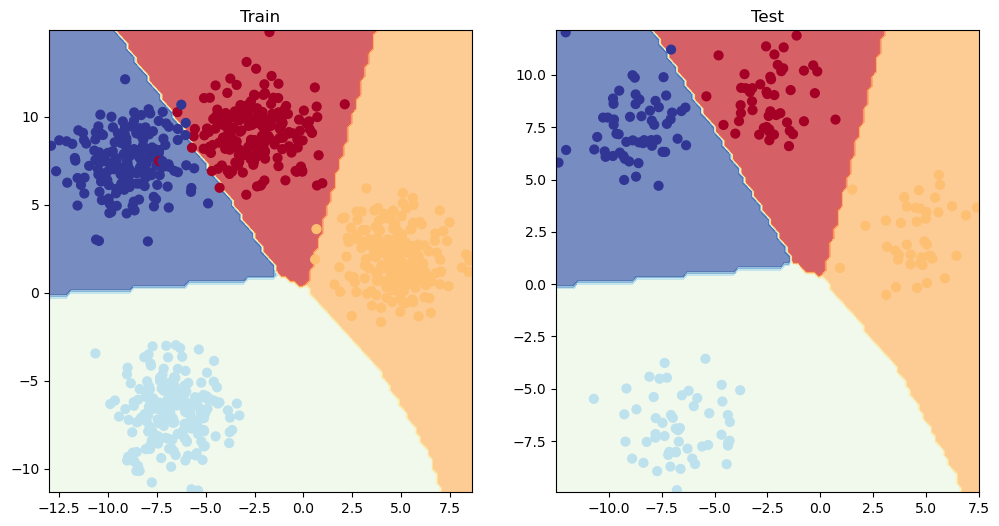

In [61]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2 ,1)
plt.title("Train")
plot_decision_boundary(model_4, X_blob_train, y_blob_train)
plt.subplot(1, 2 ,2)
plt.title("Test")
plot_decision_boundary(model_4, X_blob_test, y_blob_test)

In [62]:
# Make Predictions
model_4.eval()
with torch.inference_mode():
  y_logits = model_4(X_blob_test)
  y_pred = torch.softmax(y_logits, dim=1).argmax(dim=1)
  # y_pred = torch.argmax(y_logits, dim=1) # SAME RESULT?!?!?!?
y_pred[:10]

tensor([1, 3, 2, 1, 0, 3, 2, 0, 2, 0])

In [63]:
y_blob_test.type(torch.LongTensor)[:10]

tensor([1, 3, 2, 1, 0, 3, 2, 0, 2, 0])

**## 9. A few more classification metrics... (to evaluate our classification model)**

* Accuracy - out of 100 samples, how many does our model get right?
* Precision
* Recall
* F1-score
* Confusion matrix
* Classification report

In [65]:
from torchmetrics import Accuracy

torchmetrics_accuracy = Accuracy(task='multiclass', num_classes=NUM_CLASSES).to(device)
torchmetrics_accuracy(y_pred, y_blob_test) # 99.5% Accuracy

ModuleNotFoundError: No module named 'torchmetrics'

# Exercises

Link: https://github.com/mrdbourke/pytorch-deep-learning/blob/main/extras/exercises/02_pytorch_classification_exercises.ipynb

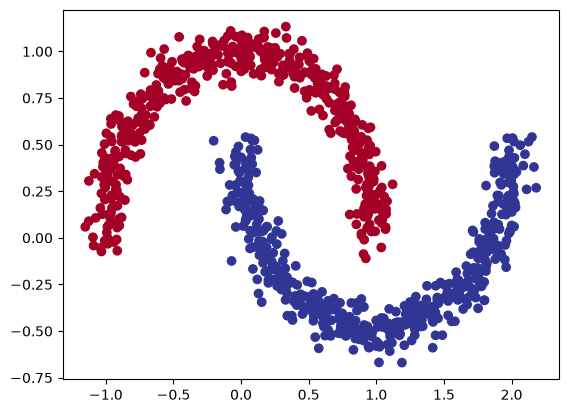

In [ ]:
# Import torch
import torch
import torch.nn as nn
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
import pandas as pd
import matplotlib.pyplot as plt
from torchmetrics.classification import BinaryAccuracy
from helper_functions import plot_predictions, plot_decision_boundary

# Setup device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"

# Setup random seed
RANDOM_SEED = 42
N_SAMPLES = 1000

X, y = make_moons(n_samples=N_SAMPLES, noise=0.07, random_state=RANDOM_SEED)

plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdYlBu)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_SEED)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((800, 2), (200, 2), (800,), (200,))

In [ ]:
X_train, y_train = torch.from_numpy(X_train).to(device).type(torch.float), torch.from_numpy(y_train).to(device).type(torch.float)
X_test, y_test = torch.from_numpy(X_test).to(device).type(torch.float), torch.from_numpy(y_test).to(device).type(torch.float)

In [ ]:
X_test.dtype

torch.float32

In [ ]:
dataframe = pd.DataFrame({"X1": X[:, 0],
              "X2": X[:, 1],
              "Y": y})
dataframe.head(10)

,X1,X2,Y
0,-0.033411,0.421391,1
1,0.998827,-0.442890,1
2,0.889592,-0.327843,1
3,0.341958,-0.417690,1
4,-0.838531,0.532375,0
5,0.599064,-0.289773,1
6,0.290090,-0.204688,1
7,-0.038269,0.459429,1
8,1.613771,-0.293970,1
9,0.693337,0.827819,0


In [ ]:
class MoonModelV1(nn.Module):
  def __init__(self, hidden_layers=24):
    super().__init__()
    self.layer_stack = nn.Sequential(
      nn.Linear(in_features=2, out_features=hidden_layers),
      nn.ReLU(),
      nn.Linear(in_features=hidden_layers, out_features=int(hidden_layers * 1.5)),
      nn.ReLU(),
      nn.Linear(in_features=int(hidden_layers * 1.5), out_features=hidden_layers),
      nn.ReLU(),
      nn.Linear(in_features=hidden_layers, out_features=1),
    )

  def forward(self, x):
    return self.layer_stack(x)

In [ ]:
moon_model = MoonModelV1().to(device)
moon_model

MoonModelV1(
  (layer_stack): Sequential(
    (0): Linear(in_features=2, out_features=24, bias=True)
    (1): ReLU()
    (2): Linear(in_features=24, out_features=36, bias=True)
    (3): ReLU()
    (4): Linear(in_features=36, out_features=24, bias=True)
    (5): ReLU()
    (6): Linear(in_features=24, out_features=1, bias=True)
  )
)

In [ ]:
moon_model.eval()
with torch.inference_mode():
  y_pred = torch.round(torch.sigmoid(moon_model(X_test).squeeze()))

print(y_pred[:10])
y_test[:10]

tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])


tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.])

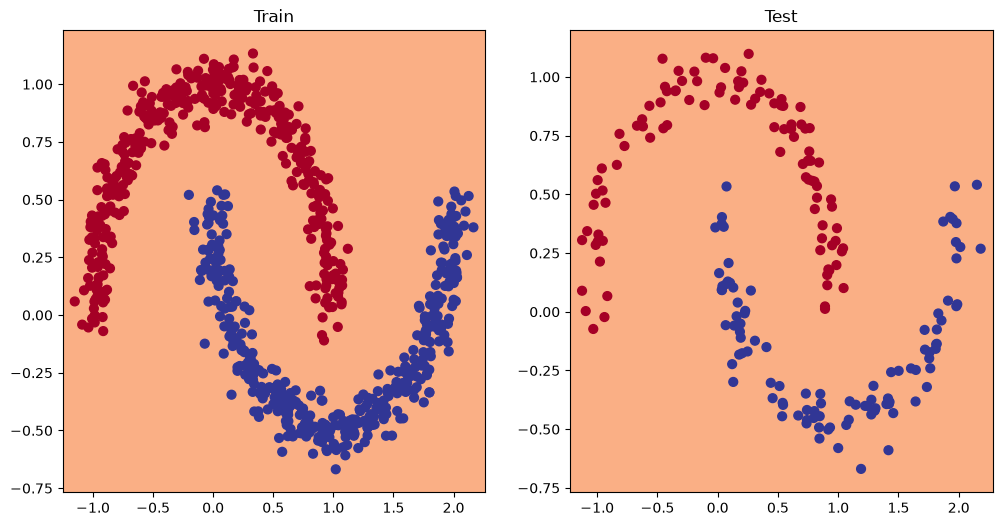

In [ ]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2 ,1)
plt.title("Train")
plot_decision_boundary(moon_model, X_train, y_train)
plt.subplot(1, 2 ,2)
plt.title("Test")
plot_decision_boundary(moon_model, X_test, y_test)

In [ ]:
loss_fn = nn.BCEWithLogitsLoss()

optimizer = torch.optim.SGD(moon_model.parameters(), lr=0.1)

In [ ]:
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)
accuracy_fn = BinaryAccuracy()

epochs = 2000

for epoch in range(epochs):
  ### Train
  moon_model.train()

  y_logits = moon_model(X_train).squeeze()
  y_pred = torch.round(torch.sigmoid(y_logits))

  loss = loss_fn(y_logits, y_train)
  acc = accuracy_fn(y_pred, y_train)

  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  ### Test
  moon_model.eval()
  with torch.inference_mode():
    test_logits = moon_model(X_test).squeeze()
    test_pred = torch.round(torch.sigmoid(test_logits))
    test_loss = loss_fn(test_logits, y_test)
    test_acc = accuracy_fn(test_pred, y_test)

  if epoch % 100 == 0:
    print(f"Epoch: {epoch} | Loss: {loss:.5f} | Accuracy: {(acc.item() * 100):.2f}% | Test Loss: {test_loss:.5f} | Test Accuracy: {(test_acc.item() * 100):.2f}%")

Epoch: 0 | Loss: 0.70062 | Accuracy: 50.00% | Test Loss: 0.69938 | Test Accuracy: 50.00%
Epoch: 100 | Loss: 0.32699 | Accuracy: 86.12% | Test Loss: 0.33419 | Test Accuracy: 85.50%
Epoch: 200 | Loss: 0.17374 | Accuracy: 92.62% | Test Loss: 0.16666 | Test Accuracy: 92.50%
Epoch: 300 | Loss: 0.08977 | Accuracy: 96.88% | Test Loss: 0.08002 | Test Accuracy: 98.00%
Epoch: 400 | Loss: 0.03455 | Accuracy: 99.37% | Test Loss: 0.02909 | Test Accuracy: 99.50%
Epoch: 500 | Loss: 0.01701 | Accuracy: 100.00% | Test Loss: 0.01372 | Test Accuracy: 100.00%
Epoch: 600 | Loss: 0.01040 | Accuracy: 100.00% | Test Loss: 0.00812 | Test Accuracy: 100.00%
Epoch: 700 | Loss: 0.00720 | Accuracy: 100.00% | Test Loss: 0.00555 | Test Accuracy: 100.00%
Epoch: 800 | Loss: 0.00541 | Accuracy: 100.00% | Test Loss: 0.00410 | Test Accuracy: 100.00%
Epoch: 900 | Loss: 0.00429 | Accuracy: 100.00% | Test Loss: 0.00320 | Test Accuracy: 100.00%
Epoch: 1000 | Loss: 0.00352 | Accuracy: 100.00% | Test Loss: 0.00259 | Test Accura

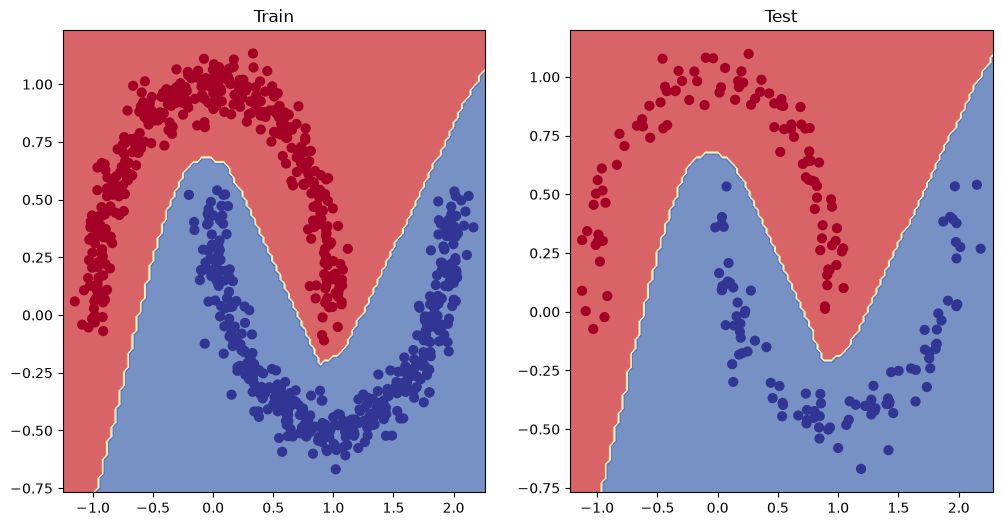

In [ ]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2 ,1)
plt.title("Train")
plot_decision_boundary(moon_model, X_train, y_train)
plt.subplot(1, 2 ,2)
plt.title("Test")
plot_decision_boundary(moon_model, X_test, y_test)

In [ ]:
import torch
import torch.nn as nn
import numpy as np
from sklearn.model_selection import train_test_split
import pandas as pd
import matplotlib.pyplot as plt
from torchmetrics.classification import Accuracy
from helper_functions import plot_decision_boundary

RANDOM_SEED = 42

N = 100 # number of points per class
D = 2 # dimensionality
K = 3 # number of classes
X = np.zeros((N*K,D)) # data matrix (each row = single example)
y = np.zeros(N*K, dtype='uint8') # class labels
for j in range(K):
  ix = range(N*j,N*(j+1))
  r = np.linspace(0.0,1,N) # radius
  t = np.linspace(j*4,(j+1)*4,N) + np.random.randn(N)*0.2 # theta
  X[ix] = np.c_[r*np.sin(t), r*np.cos(t)]
  y[ix] = j

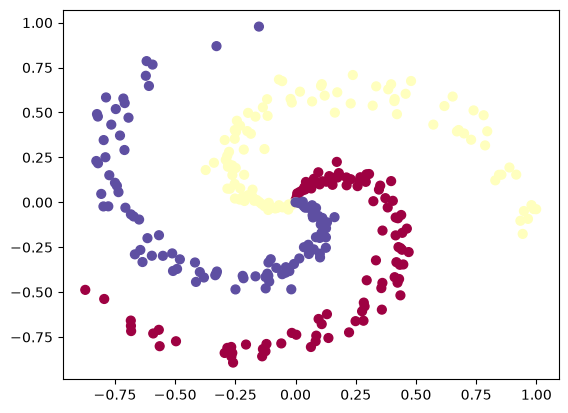

In [ ]:
plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.Spectral)
plt.show()


In [ ]:
X, y

(array([[-0.00000000e+00,  0.00000000e+00],
        [-6.24464927e-04,  1.00816888e-02],
        [ 4.47542589e-03,  1.97000554e-02],
        [ 5.00424520e-03,  2.98869733e-02],
        [ 8.57165567e-03,  3.94843412e-02],
        [ 7.18187880e-03,  4.99918068e-02],
        [ 1.78432113e-02,  5.79198964e-02],
        [ 2.73811789e-02,  6.51901901e-02],
        [ 3.90009565e-02,  7.07733800e-02],
        [ 3.65428134e-02,  8.32411292e-02],
        [ 6.53151500e-02,  7.70517468e-02],
        [ 5.11834975e-02,  9.86201227e-02],
        [ 4.31920813e-02,  1.13255563e-01],
        [ 7.74351265e-02,  1.06051590e-01],
        [ 1.00208741e-01,  9.97805974e-02],
        [ 7.62609984e-02,  1.30924029e-01],
        [ 1.11591900e-01,  1.16906080e-01],
        [ 1.27881766e-01,  1.14599481e-01],
        [ 1.53583049e-01,  9.73144299e-02],
        [ 9.45896465e-02,  1.66990344e-01],
        [ 1.39992347e-01,  1.45651312e-01],
        [ 1.62178396e-01,  1.36724455e-01],
        [ 1.74192209e-01,  1.379

In [ ]:
X.shape, y.shape

((300, 2), (300,))

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [ ]:
X, y = torch.from_numpy(X).type(torch.float), torch.from_numpy(y).type(torch.LongTensor)
X, y = X.to(device), y.to(device)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_SEED)

In [ ]:
class SpiralModelV1(nn.Module):
  def __init__(self, hidde_layers=24, in_features=2, out_feature=3):
    super().__init__()
    self.stacked_layers = nn.Sequential(
      nn.Linear(in_features=in_features, out_features=hidde_layers),
      nn.ReLU(),
      nn.Linear(in_features=hidde_layers, out_features=int(hidde_layers * 1.5)),
      nn.ReLU(),
      nn.Linear(in_features=int(hidde_layers * 1.5), out_features=hidde_layers),
      nn.ReLU(),
      nn.Linear(in_features=hidde_layers, out_features=out_feature),
    )

  def forward(self, x):
    return self.stacked_layers(x)

In [ ]:
spiral_model = SpiralModelV1().to(device)
spiral_model

SpiralModelV1(
  (stacked_layers): Sequential(
    (0): Linear(in_features=2, out_features=24, bias=True)
    (1): ReLU()
    (2): Linear(in_features=24, out_features=36, bias=True)
    (3): ReLU()
    (4): Linear(in_features=36, out_features=24, bias=True)
    (5): ReLU()
    (6): Linear(in_features=24, out_features=3, bias=True)
  )
)

In [ ]:
spiral_model.eval()
with torch.inference_mode():
  y_pred = torch.softmax(spiral_model(X_test), dim=1).argmax(dim=1)
  
y_pred[:10]

tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [ ]:
y_test[:10]

tensor([2, 2, 1, 0, 2, 2, 1, 1, 0, 1])

In [ ]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(spiral_model.parameters(), lr=0.1)
accuracy_fn = Accuracy(task='multiclass', num_classes=3)

In [ ]:
X_train, X_test = X_train.to(device), X_test.to(device)
y_train, y_test = y_train.to(device), y_test.to(device)

epochs = 1000

for epoch in range(epochs):
  ### Train
  spiral_model.train()

  y_logits = spiral_model(X_train)
  y_pred = torch.softmax(y_logits, dim=1).argmax(dim=1)

  loss = loss_fn(y_logits, y_train)
  acc = accuracy_fn(y_pred, y_train)

  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  ### Test
  spiral_model.eval()
  with torch.inference_mode():
    test_logits = spiral_model(X_test)
    test_pred = torch.softmax(test_logits, dim=1).argmax(dim=1)
    test_loss = loss_fn(test_logits, y_test)
    test_acc = accuracy_fn(test_pred, y_test)

  if epoch % 100 == 0:
    print(f"Epoch: {epoch} | Loss: {loss:.5f} | Accuracy: {(acc.item() * 100):.2f}% | Test Loss: {test_loss:.5f} | Test Accuracy: {(test_acc.item() * 100):.2f}%")


Epoch: 0 | Loss: 0.03767 | Accuracy: 98.75% | Test Loss: 0.02360 | Test Accuracy: 98.33%
Epoch: 100 | Loss: 0.03629 | Accuracy: 99.17% | Test Loss: 0.02173 | Test Accuracy: 98.33%
Epoch: 200 | Loss: 0.03510 | Accuracy: 99.17% | Test Loss: 0.02020 | Test Accuracy: 98.33%
Epoch: 300 | Loss: 0.03402 | Accuracy: 99.17% | Test Loss: 0.01885 | Test Accuracy: 98.33%
Epoch: 400 | Loss: 0.03302 | Accuracy: 99.17% | Test Loss: 0.01759 | Test Accuracy: 98.33%
Epoch: 500 | Loss: 0.03215 | Accuracy: 99.17% | Test Loss: 0.01654 | Test Accuracy: 98.33%
Epoch: 600 | Loss: 0.03140 | Accuracy: 99.17% | Test Loss: 0.01567 | Test Accuracy: 98.33%
Epoch: 700 | Loss: 0.03069 | Accuracy: 99.17% | Test Loss: 0.01486 | Test Accuracy: 100.00%
Epoch: 800 | Loss: 0.03005 | Accuracy: 99.17% | Test Loss: 0.01416 | Test Accuracy: 100.00%
Epoch: 900 | Loss: 0.02947 | Accuracy: 99.17% | Test Loss: 0.01350 | Test Accuracy: 100.00%


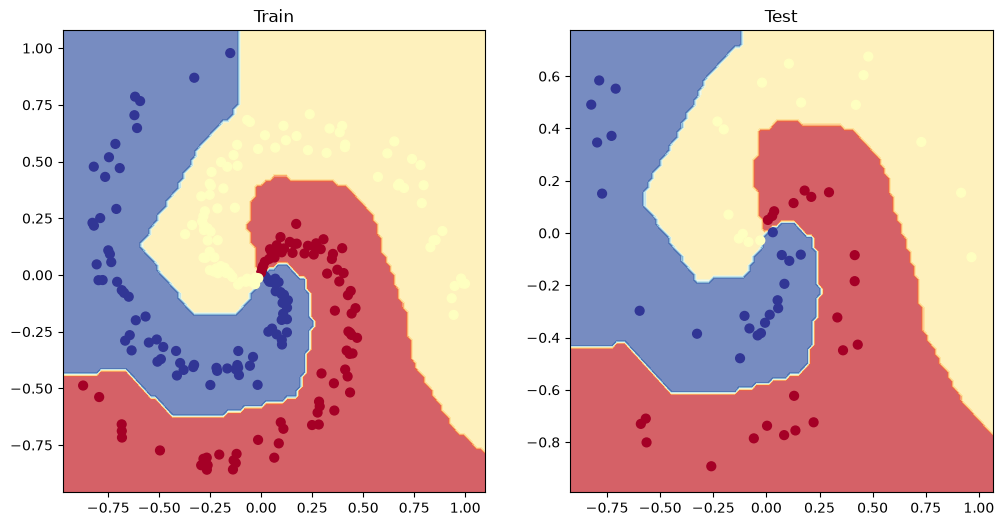

In [ ]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2 ,1)
plt.title("Train")
plot_decision_boundary(spiral_model, X_train, y_train)
plt.subplot(1, 2 ,2)
plt.title("Test")
plot_decision_boundary(spiral_model, X_test, y_test)